In [2]:
%load_ext autoreload
%autoreload 2

In [15]:
from src.module import Module
from src.dm import DataModule
from src.ds import Dataset
from torch.utils.data import DataLoader
import albumentations as A
import os
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm
import pandas as pd
import ast
import rasterio as rio
from pathlib import Path
import numpy as np
import tifffile
from concurrent.futures import ThreadPoolExecutor

In [16]:
os.listdir('checkpoints')

['himawari-epoch=66-val_rmse=0.8166.ckpt',
 'meteosat-epoch=53-val_rmse=0.5751.ckpt',
 'epoch=19-val_rmse=0.7176.ckpt',
 'epoch=0-val_rmse=0.7080.ckpt',
 'all-epoch=53-val_rmse=0.7277.ckpt',
 'goes-epoch=81-val_rmse=0.8102.ckpt']

In [4]:
module = Module.load_from_checkpoint('checkpoints/epoch=0-val_rmse=0.7080.ckpt')
module.cuda()
module.eval();

# Evaluation

In [5]:
trans = A.Compose([
    # A.Resize(32, 32)
    A.Resize(64, 64)
], additional_targets={'image1': 'image', 'image2': 'image', 'image3': 'image'})

dm = DataModule(
    batch_size=1,
    num_workers=0,
    pin_memory=False,
    train_trans=trans,
    val_trans=trans,
    num_frames=3,
    min_obs=3,
    num_obs=3,
    importance_sampling=False
)

dm.setup()

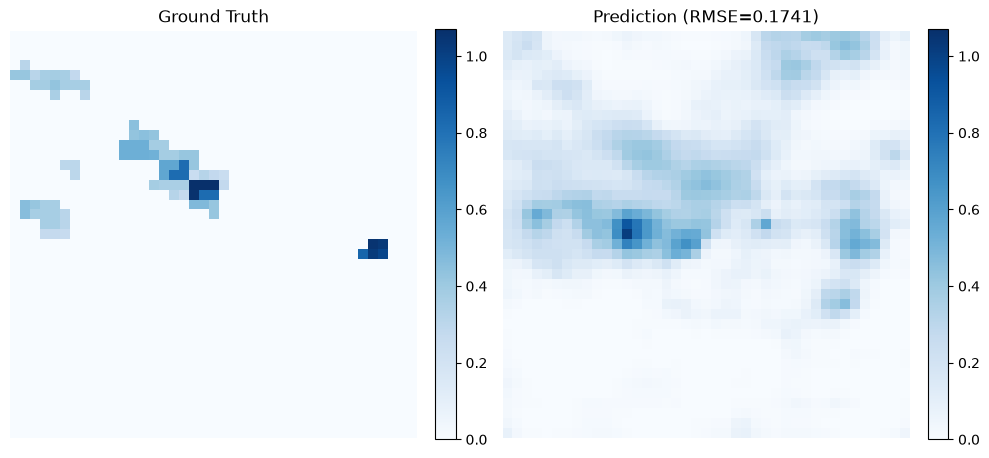

In [6]:
batch = next(iter(dm.val_dataloader(shuffle=True)))
with torch.no_grad():
    y_pred = module.model.predict_regression(batch['inputs'].cuda())

y_pred_np = y_pred.squeeze().cpu().numpy()
y_true_np = batch['target'].squeeze().cpu().numpy()

# Compute RMSE for the displayed sample
rmse = ((y_pred_np - y_true_np) ** 2).mean() ** 0.5

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

vmin = 0
vmax = max(y_true_np.max(), y_pred_np.max())
im0 = axs[0].imshow(y_true_np, cmap='Blues', vmin=vmin, vmax=vmax)
im1 = axs[1].imshow(y_pred_np, cmap='Blues', vmin=vmin, vmax=vmax)

axs[0].set_title('Ground Truth')
axs[0].axis('off')
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

axs[1].set_title(f'Prediction (RMSE={rmse:.4f})')
axs[1].axis('off')
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [17]:
checkpoints = [
    'checkpoints/himawari-epoch=66-val_rmse=0.8166.ckpt',
    'checkpoints/meteosat-epoch=53-val_rmse=0.5751.ckpt',
    'checkpoints/goes-epoch=81-val_rmse=0.8102.ckpt',
]

In [22]:
rmses = []
for checkpoint in checkpoints:
    trans = A.Compose([
        A.Resize(32, 32)
    ], additional_targets={'image1': 'image', 'image2': 'image', 'image3': 'image'})

    satellite = checkpoint.split('/')[1].split('-')[0]
    print(satellite)

    dm = DataModule(
        batch_size=100,
        num_workers=10,
        pin_memory=True,
        train_trans=trans,
        val_trans=trans,
        num_frames=4,
        min_obs=3,
        num_obs=3,
        importance_sampling=False,
        satellite_target=satellite
    )

    dm.setup()

    module = Module.load_from_checkpoint(checkpoint)
    module.cuda()
    module.eval()

    @torch.no_grad()
    def compute_global_rmse(model, dataloader):
        sse = 0.0
        n_pixels = 0
        for batch in tqdm(dataloader, desc='Evaluating'):
            x = batch['inputs'].cuda()
            y = batch['target'].cuda()
            y_pred = model.model.predict_regression(x)
            sse += ((y_pred - y) ** 2).sum().item()
            n_pixels += y.numel()
        return (sse / n_pixels) ** 0.5
        
    val_rmse = compute_global_rmse(module, dm.val_dataloader(shuffle=False))
    print(f'Validation RMSE (global, mm/h): {val_rmse:.4f}')
    rmses.append(val_rmse)

if rmses:
    avg_rmse = sum(rmses) / len(rmses)
    print(f'Average Validation RMSE across all satellites: {avg_rmse:.4f}')

himawari
Loading pretrained SaTformer weights from: weights/sf-64-cls.pt


Evaluating: 100%|██████████| 26/26 [00:16<00:00,  1.59it/s]


Validation RMSE (global, mm/h): 0.8338
meteosat
Loading pretrained SaTformer weights from: weights/sf-64-cls.pt


Evaluating: 100%|██████████| 34/34 [00:22<00:00,  1.50it/s]


Validation RMSE (global, mm/h): 0.5886
goes
Loading pretrained SaTformer weights from: weights/sf-64-cls.pt


Evaluating: 100%|██████████| 21/21 [00:14<00:00,  1.42it/s]

Validation RMSE (global, mm/h): 0.8278
Average Validation RMSE across all satellites: 0.7501


# Submission

In [9]:
evaluation = pd.read_csv('data/evaluation_target.csv')
evaluation['last_30_minutes_observation_filename'] = evaluation['last_30_minutes_observation_filename'].apply(ast.literal_eval)
evaluation

,unique_id,name_location,satellite_target,datetime,last_30_minutes_observation_filename,gpm_imerg_filename
0,d89c-865b,kanto_region,himawari,2023-01-01 00:00:00,"[test_kanto_region_Himawari_20221231_2330.tif,...",test_kanto_region_GPM_IMERG_2023-01-01_00-00-0...
1,4372-d9ff,kanto_region,himawari,2023-01-01 00:30:00,"[test_kanto_region_Himawari_20230101_0000.tif,...",test_kanto_region_GPM_IMERG_2023-01-01_00-30-0...
2,c085-cb78,kanto_region,himawari,2023-01-01 01:00:00,"[test_kanto_region_Himawari_20230101_0030.tif,...",test_kanto_region_GPM_IMERG_2023-01-01_01-00-0...
3,04f9-69bb,kanto_region,himawari,2023-01-01 01:30:00,"[test_kanto_region_Himawari_20230101_0100.tif,...",test_kanto_region_GPM_IMERG_2023-01-01_01-30-0...
4,7891-4979,kanto_region,himawari,2023-01-01 02:00:00,"[test_kanto_region_Himawari_20230101_0130.tif,...",test_kanto_region_GPM_IMERG_2023-01-01_02-00-0...
...,...,...,...,...,...,...
29085,6b66-e372,valencia,meteosat,2025-12-31 21:30:00,"[test_valencia_Meteosat_20251231_2100.tif, tes...",test_valencia_GPM_IMERG_2025-12-31_21-30-00.tif
29086,c27c-142b,valencia,meteosat,2025-12-31 22:00:00,"[test_valencia_Meteosat_20251231_2130.tif, tes...",test_valencia_GPM_IMERG_2025-12-31_22-00-00.tif
29087,9a7e-fa48,valencia,meteosat,2025-12-31 22:30:00,"[test_valencia_Meteosat_20251231_2200.tif, tes...",test_valencia_GPM_IMERG_2025-12-31_22-30-00.tif
29088,b8aa-832a,valencia,meteosat,2025-12-31 23:00:00,"[test_valencia_Meteosat_20251231_2230.tif, tes...",test_valencia_GPM_IMERG_2025-12-31_23-00-00.tif


In [10]:
os.listdir('checkpoints')

['himawari-epoch=66-val_rmse=0.8166.ckpt',
 'meteosat-epoch=53-val_rmse=0.5751.ckpt',
 'epoch=19-val_rmse=0.7176.ckpt',
 'epoch=0-val_rmse=0.7080.ckpt',
 'goes-epoch=81-val_rmse=0.8102.ckpt',
 'all-epoch=49-val_rmse=0.7282.ckpt']

In [11]:
checkpoints = [
    'checkpoints/himawari-epoch=66-val_rmse=0.8166.ckpt',
    'checkpoints/meteosat-epoch=53-val_rmse=0.5751.ckpt',
    'checkpoints/goes-epoch=81-val_rmse=0.8102.ckpt',
]

In [12]:
for checkpoint in checkpoints:
    satellite = checkpoint.split('/')[1].split('-')[0]
    print(satellite)
    
    trans = A.Compose([
        A.Resize(32, 32)
    ], additional_targets={'image1': 'image', 'image2': 'image', 'image3': 'image'})

    _evaluation = evaluation[evaluation['satellite_target'] == satellite]

    dataset = Dataset(
        path=Path('data'),
        data=_evaluation,
        trans=trans,
        num_obs=3,
        num_frames=4,
        return_target=False,
    )

    dataloader = DataLoader(
        dataset,
        batch_size=100,
        num_workers=20,
        pin_memory=False,
    )

    module = Module.load_from_checkpoint(checkpoint)
    module.cuda()
    module.eval()

    OUT_DIR = Path('submission/test_files')
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    def write_tif(pred, fname):
        tifffile.imwrite(OUT_DIR / fname, np.clip(pred.squeeze(), 0, None).astype(np.float32))

    with torch.inference_mode():
        with ThreadPoolExecutor(max_workers=8) as pool:
            for batch in tqdm(dataloader):
                preds = module.model.predict_regression(
                    batch['inputs'].cuda()
                ).cpu().numpy()
                list(pool.map(write_tif, preds, batch['gpm_imerg_filename']))

himawari
Loading pretrained SaTformer weights from: weights/sf-64-cls.pt


100%|██████████| 118/118 [01:13<00:00,  1.60it/s]


meteosat
Loading pretrained SaTformer weights from: weights/sf-64-cls.pt


100%|██████████| 101/101 [01:03<00:00,  1.59it/s]


goes
Loading pretrained SaTformer weights from: weights/sf-64-cls.pt


100%|██████████| 73/73 [00:50<00:00,  1.46it/s]


In [13]:
import shutil
import zipfile
import os

# Copy evaluation csv to the submission folder
src_csv = 'data/evaluation_target.csv'
dst_csv = 'submission/evaluation_target.csv'
shutil.copyfile(src_csv, dst_csv)

# Zip the entire submission folder (including test_files and any .csv files)
zip_path = 'submission.zip'
submission_folder = 'submission'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(submission_folder):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, submission_folder)
            zipf.write(file_path, arcname=os.path.join('submission', arcname))

In [14]:
# --- Validate Submission ---

print('=== Submission Validation ===')
errors = []

# 1. CSV exists
if not os.path.exists(dst_csv):
    errors.append('Missing evaluation_target.csv')
else:
    print('✓ evaluation_target.csv exists')

# 2. Required columns
sub_df = pd.read_csv(dst_csv)
required_cols = {'unique_id', 'gpm_imerg_filename'}
if not required_cols.issubset(set(sub_df.columns)):
    errors.append(f'Missing columns: {required_cols - set(sub_df.columns)}')
else:
    print('✓ Required columns present')

# 3. No nulls
if sub_df[['unique_id', 'gpm_imerg_filename']].isnull().any().any():
    errors.append('Null values found')
else:
    print('✓ No null values')

# 4. All unique_ids present
required_ids = set(evaluation['unique_id'])
submitted_ids = set(sub_df['unique_id'])
missing_ids = required_ids - submitted_ids
if missing_ids:
    errors.append(f'Missing {len(missing_ids)} unique_ids')
else:
    print(f'✓ All {len(required_ids):,} unique_ids present')

# 5. No duplicates
if sub_df['unique_id'].duplicated().any():
    errors.append('Duplicate unique_ids')
else:
    print('✓ No duplicate unique_ids')

# 6. All TIF files exist and are readable
missing_tifs = []
for _, row in sub_df.iterrows():
    fpath = os.path.join('submission/test_files', row['gpm_imerg_filename'])
    if not os.path.exists(fpath):
        missing_tifs.append(row['gpm_imerg_filename'])
if missing_tifs:
    errors.append(f'{len(missing_tifs)} TIF files missing')
else:
    print(f'✓ All {len(sub_df):,} TIF files present')

# 7. Dimensions check
sample_pred = os.path.join('submission/test_files', os.listdir('submission/test_files')[0])
with rio.open(sample_pred) as src:
    if (src.width, src.height) != (41, 41):
        errors.append(f'Dimension mismatch: {src.width}×{src.height} vs (41, 41)')
    else:
        print(f'✓ Dimensions correct ({src.width}×{src.height})')

if errors:
    print(f'\n✗ FAILED ({len(errors)} errors):')
    for e in errors:
        print(f'  - {e}')
else:
    print(f'\n✓ ALL CHECKS PASSED — ready for upload!')

=== Submission Validation ===
✓ evaluation_target.csv exists
✓ Required columns present
✓ No null values
✓ All 29,090 unique_ids present
✓ No duplicate unique_ids
✓ All 29,090 TIF files present
✓ Dimensions correct (41×41)

✓ ALL CHECKS PASSED — ready for upload!


/home/juan/Desktop/competis/.venv/lib/python3.12/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
